In [171]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

In [172]:
N_SIM = 1000
n_periods = 8
mu_ibap_price,sigma_ibap_price = 1.6467,0.035
mu_HF_price,sigma_HF_price = 0.0198, 0.0876
mu_HF_throughput,sigma_HF_throughput = 294480, 121.34
mu_ibap_throughput,sigma_ibap_throughput = 578880,170.29
mu_raw_mat,sigma_raw_mat = 3136440,313644
mu_inflation,sigma_inflation = 2,2.25



# Stochastic Drivers (Vectorised for speed)
#  draw all samples at once for each driver
price_of_ibap = np.random.normal(loc=mu_ibap_price, scale=sigma_ibap_price, size=(N_SIM, n_periods))
price_of_ibap = np.exp(price_of_ibap)  # Convert log-price to price

price_of_HF = np.random.normal(loc=mu_HF_price, scale=sigma_HF_price, size=(N_SIM, n_periods))
price_of_HF = np.exp(price_of_HF)  # Convert log-price to price

HF_throughput = np.random.normal(loc=mu_HF_throughput, scale=sigma_HF_throughput, size=(N_SIM, n_periods))
ibap_throughput = np.random.normal(loc=mu_ibap_throughput, scale=sigma_ibap_throughput, size=(N_SIM, n_periods))
raw_material_cost = np.random.normal(loc=mu_raw_mat, scale=sigma_raw_mat, size=(N_SIM, n_periods))
inflation = np.random.normal(loc=mu_inflation, scale=sigma_inflation, size=(N_SIM, n_periods))


In [173]:
print(price_of_ibap[:5,:20])
print(price_of_HF[:5,:20])

[[5.36064259 5.11189994 5.21898553 5.13953458 5.22032438 5.21463091
  5.22177662 5.23557954]
 [5.38998526 4.99046782 5.04874179 5.28721984 5.04200973 4.98061725
  5.43519884 5.24259241]
 [5.06682377 4.95305979 5.28178337 5.2552331  5.19916867 5.41954229
  5.08853233 4.87861082]
 [5.26387156 4.98338601 5.06364599 5.17681721 5.09389838 5.31324767
  4.98199354 5.41450756]
 [4.95529673 5.28059488 5.19335621 5.17995152 5.49651691 4.85791552
  5.23562384 4.85900551]]
[[0.93758101 0.9302512  1.12521681 0.99630349 1.02176647 0.98267695
  0.91207238 1.00482401]
 [0.93590569 0.97242297 0.97582683 1.02274082 1.11826581 1.09991769
  0.92129752 1.06052489]
 [1.14641853 0.9689756  1.02706638 1.08205035 0.89625243 1.06795724
  1.07446386 0.95004822]
 [0.98262748 1.0532653  1.04838224 1.0363539  0.96401422 1.08201196
  1.02757555 1.04996071]
 [0.9330563  1.159331   1.01437022 1.00143526 1.11141888 1.04777106
  1.07662662 0.95842628]]


In [ ]:
def npv_vectorized(price_of_ibap, ibap_throughput, 
                   price_of_HF,HF_throughput,
                   raw_material_cost, inflation, discount_rate):
    periods = price_of_ibap.shape[1]
    t = np.arange(1, periods + 1)

    revenue = price_of_ibap * ibap_throughput + price_of_HF * HF_throughput
    cost = raw_material_cost * (1 + inflation) ** t
    net_cash_flow = revenue - cost
    discounted_cash_flow = net_cash_flow / (1 + discount_rate) ** t

    return discounted_cash_flow   # one NPV per simulation


# All stochastic drivers intact

In [175]:
npv_results = npv_vectorized(
    price_of_ibap,
    ibap_throughput,
    price_of_HF,HF_throughput,
    raw_material_cost,
    inflation,
    # Baseline in lecture notes
    discount_rate=0.15
)


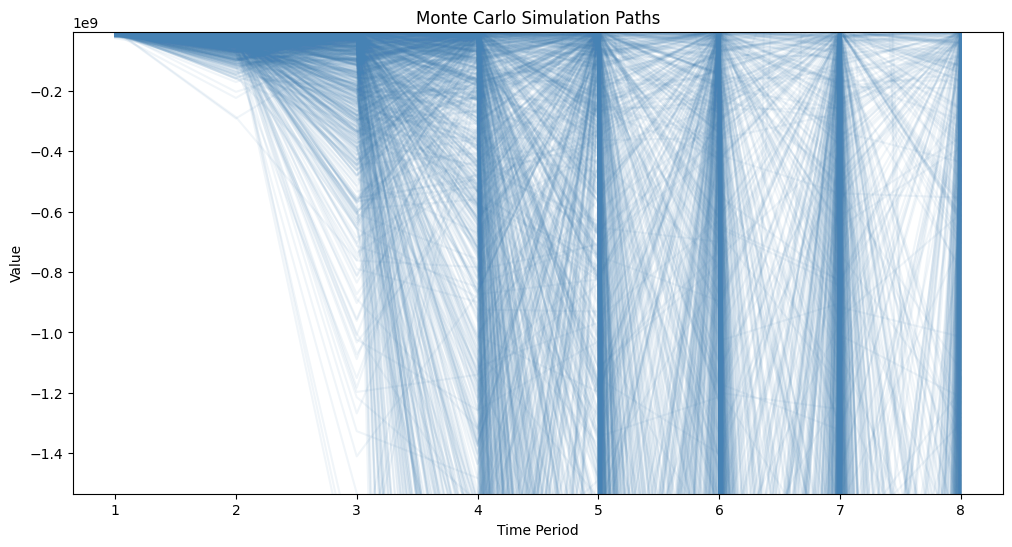

In [176]:
plt.figure(figsize=(12, 6))

for i in range(npv_results.shape[0]):
    plt.plot(range(1, npv_results.shape[1] + 1), npv_results[i], alpha=0.08, color="steelblue")

# Set y-limits using percentiles to ignore extreme outliers
ymin = np.percentile(npv_results, 25)
ymax = np.percentile(npv_results, 75)
plt.ylim(ymin, ymax)

plt.xlabel("Time Period")
plt.ylabel("Value")
plt.title("Monte Carlo Simulation Paths")
plt.show()

# Only Price of IBAP and HF is stochastic & changing their parameters

- Exploring different characteristics of the stochastic drivers


Before:
iBAP_Price - log normal ~ (1.6467,0.035)
HF_Price - log normal ~ (0.0198,0.0876)

After
iBAP_Price - log normal ~ (1.6467,0.0219)
HF_Price - lognormal ~ (0.0198,0.00219)




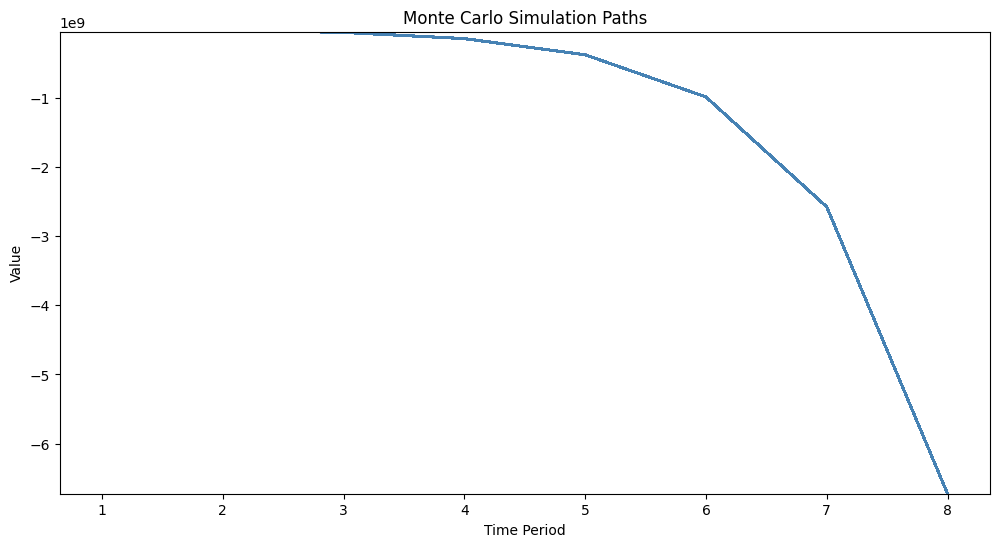

In [180]:
price_of_ibap = np.random.normal(loc=1.6467, scale=0.17527, size=(N_SIM, n_periods))
price_of_ibap = np.exp(price_of_ibap)  # Convert log-price to price

price_of_HF = np.random.normal(loc=0.0198, scale=0.1095, size=(N_SIM, n_periods))
price_of_HF = np.exp(price_of_HF)  # Convert log-price to price

npv_results = npv_vectorized(
    price_of_ibap,
    ibap_throughput,
    price_of_HF,HF_throughput,
    3136440,
    2,
    discount_rate=0.15 # Baseline in lecture notes
)




plt.figure(figsize=(12, 6))

for i in range(npv_results.shape[0]):
    plt.plot(range(1, npv_results.shape[1] + 1), npv_results[i], alpha=0.3, color="steelblue")

# Set y-limits using percentiles to ignore extreme outliers
ymin = np.percentile(npv_results, 5)
ymax = np.percentile(npv_results, 75)
plt.ylim(ymin, ymax)

plt.xlabel("Time Period")
plt.ylabel("Value")
plt.title("Monte Carlo Simulation Paths")
plt.show()

In [178]:
# Checks 
price_of_ibap[:2,:20]

array([[5.13041296, 6.26587235, 5.6392608 , 7.75254136, 5.8455699 ,
        4.02756645, 5.77478847, 6.0445089 ],
       [4.35375786, 5.78074052, 3.66597545, 5.50920312, 6.57646692,
        4.72383414, 4.52555004, 5.27847957]])

# Only Inflation is stochastic

In [ ]:

npv_results = npv_vectorized(
    5.19,
    ibap_throughput,
    price_of_HF,HF_throughput,
    3136440,
    2,
    discount_rate=0.15 # Baseline in lecture notes
)




plt.figure(figsize=(12, 6))

for i in range(npv_results.shape[0]):
    plt.plot(range(1, npv_results.shape[1] + 1), npv_results[i], alpha=0.3, color="steelblue")

# Set y-limits using percentiles to ignore extreme outliers
ymin = np.percentile(npv_results, 5)
ymax = np.percentile(npv_results, 75)
plt.ylim(ymin, ymax)

plt.xlabel("Time Period")
plt.ylabel("Value")
plt.title("Monte Carlo Simulation Paths")
plt.show()